In [1]:
import sys
sys.path.append("../src")

import torch
import torch.nn as nn
import torchvision.models as models
import matplotlib.pyplot as plt
import numpy as np

In [2]:
model = models.resnet18(weights=None)

model.fc = nn.Linear(
    model.fc.in_features,
    4
)

model.load_state_dict(
    torch.load(
        "../models/resnet18_brain_tumor.pth",
        map_location="cpu"
    )
)

model.eval()

print("Model loaded successfully!")

Model loaded successfully!


In [3]:
from brisc_project.brisc import get_data_loader

test_loader, classes = get_data_loader(
    "../brain_tumor/brisc2025/classification_task/test",
    batch_size=1
)

image, label = next(iter(test_loader))

with torch.no_grad():
    output = model(image)
    prediction = output.argmax(dim=1)

print("Actual:", classes[label.item()])
print("Predicted:", classes[prediction.item()])

Actual: meningioma
Predicted: meningioma


In [4]:
correct_image = None
correct_label = None
correct_prediction = None

model.eval()

with torch.no_grad():
    for image, label in test_loader:
        output = model(image)
        prediction = output.argmax(dim=1)

        actual_class = classes[label.item()]
        predicted_class = classes[prediction.item()]

        if actual_class != "no_tumor" and actual_class == predicted_class:
            correct_image = image
            correct_label = label
            correct_prediction = prediction
            break

print("Actual:", classes[correct_label.item()])
print("Predicted:", classes[correct_prediction.item()])

Actual: meningioma
Predicted: meningioma


In [5]:
image, label = next(iter(test_loader))

In [6]:
torch.save(
    model.state_dict(),
    "../models/resnet18_brain_tumor.pth"
)

In [7]:
activations = None
gradients = None

def forward_hook(module, input, output):
    global activations
    activations = output

def backward_hook(module, grad_input, grad_output):
    global gradients
    gradients = grad_output[0]

target_layer = model.layer4[-1]

forward_handle = target_layer.register_forward_hook(forward_hook)
backward_handle = target_layer.register_full_backward_hook(backward_hook)

In [8]:
model.zero_grad()

output = model(correct_image)

class_idx = correct_prediction.item()
score = output[:, class_idx]

score.backward()

In [9]:
weights = gradients.mean(dim=(2, 3), keepdim=True)

cam = (weights * activations).sum(dim=1).squeeze()

cam = torch.relu(cam)

cam = cam - cam.min()
cam = cam / cam.max()

cam = cam.detach().numpy()

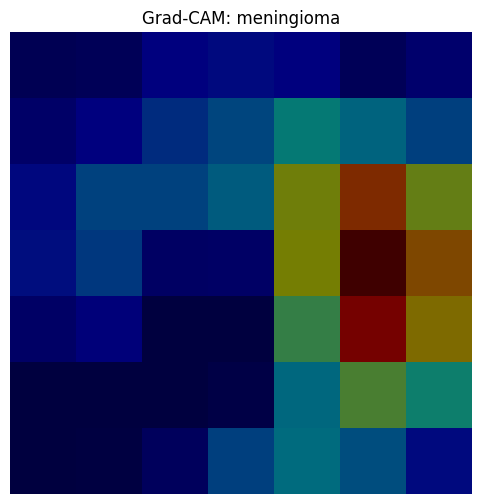

In [10]:
import matplotlib.pyplot as plt
import numpy as np

img = correct_image.squeeze().permute(1, 2, 0).numpy()

plt.figure(figsize=(6, 6))
plt.imshow(img, cmap="gray")
plt.imshow(cam, cmap="jet", alpha=0.5)
plt.title(f"Grad-CAM: {classes[class_idx]}")
plt.axis("off")
plt.show()

In [11]:
from captum.attr import IntegratedGradients

ig = IntegratedGradients(model)

attributions = ig.attribute(
    correct_image,
    target=correct_prediction.item()
)

C:\Users\ccai2\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


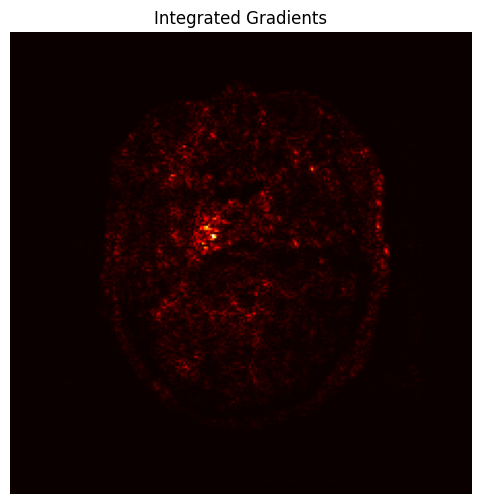

In [12]:
attr = attributions.squeeze().permute(1, 2, 0).detach().numpy()

plt.figure(figsize=(6,6))
plt.imshow(np.mean(np.abs(attr), axis=2), cmap="hot")
plt.title("Integrated Gradients")
plt.axis("off")
plt.show()

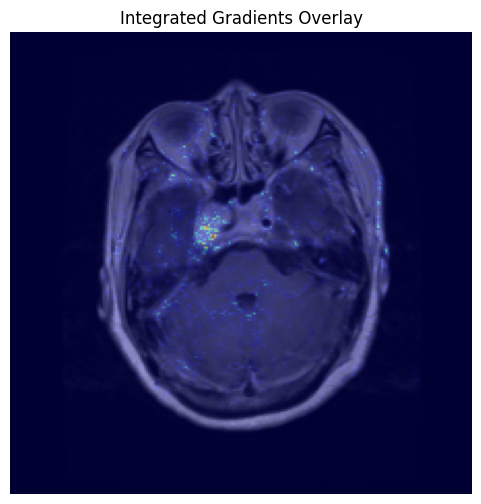

In [13]:
attr = np.mean(np.abs(attr), axis=2)

attr = (attr - attr.min()) / (attr.max() - attr.min())

img = correct_image.squeeze().permute(1, 2, 0).numpy()

plt.figure(figsize=(6,6))
plt.imshow(img, cmap="gray")
plt.imshow(attr, cmap="jet", alpha=0.4)
plt.title("Integrated Gradients Overlay")
plt.axis("off")
plt.show()

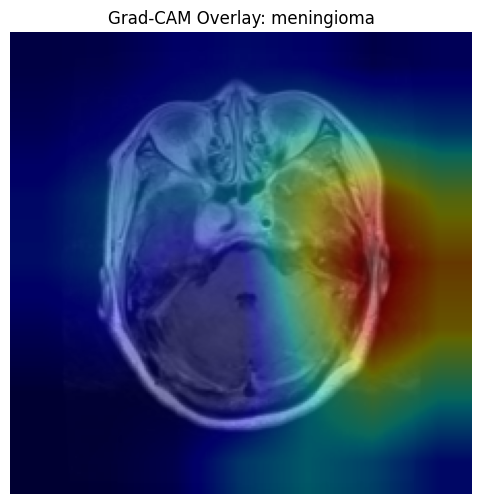

In [15]:
import cv2
import matplotlib.pyplot as plt

img = correct_image.squeeze().permute(1, 2, 0).numpy()

cam_resized = cv2.resize(
    cam,
    (img.shape[1], img.shape[0])
)

plt.figure(figsize=(6, 6))
plt.imshow(img, cmap="gray")
plt.imshow(cam_resized, cmap="jet", alpha=0.4)
plt.title(f"Grad-CAM Overlay: {classes[class_idx]}")
plt.axis("off")
plt.show()

In [16]:
import os

seg_path ="../brain_tumor/brisc2025/segmentation_task"

print(os.listdir(seg_path))

['test', 'train']


In [17]:
print(os.listdir(seg_path + r"\train")[:10])

['images', 'masks']


In [19]:
import os

image_dir = "../brain_tumor/brisc2025/segmentation_task/test/images"
mask_dir = "../brain_tumor/brisc2025/segmentation_task/test/masks"

image_files = sorted(os.listdir(image_dir))
mask_files = sorted(os.listdir(mask_dir))

print(image_files[0])
print(mask_files[0])

brisc2025_test_00001_gl_ax_t1.jpg
brisc2025_test_00001_gl_ax_t1.png


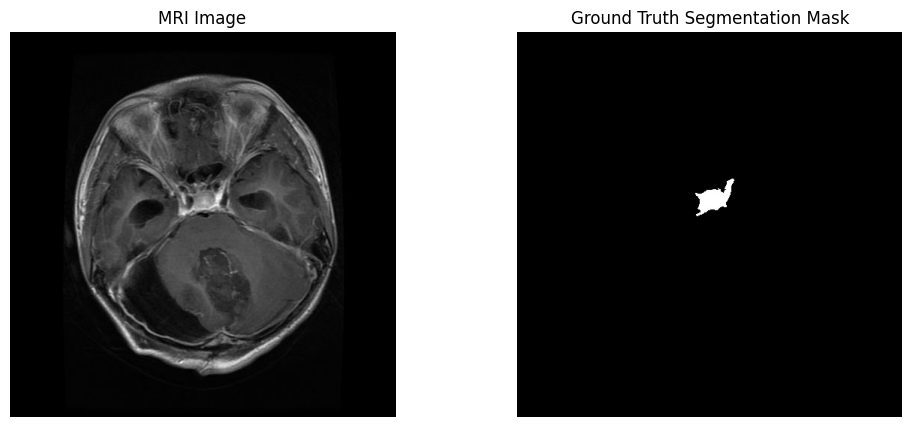

In [20]:
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import os

img_path = os.path.join(image_dir, image_files[0])
mask_path = os.path.join(mask_dir, mask_files[0])

img = np.array(Image.open(img_path))
mask = np.array(Image.open(mask_path))

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(img, cmap="gray")
plt.title("MRI Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(mask, cmap="gray")
plt.title("Ground Truth Segmentation Mask")
plt.axis("off")

plt.show()

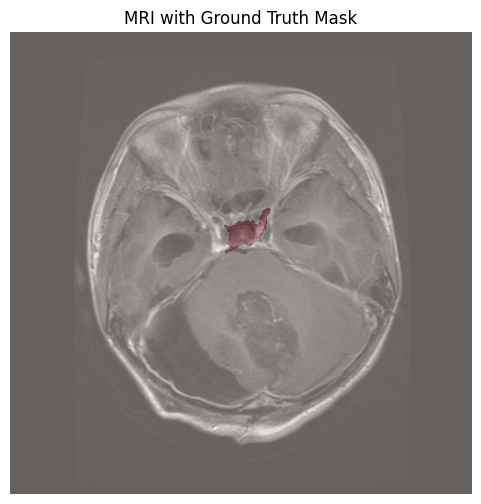

In [21]:
plt.figure(figsize=(6, 6))
plt.imshow(img, cmap="gray")
plt.imshow(mask, cmap="Reds", alpha=0.4)
plt.title("MRI with Ground Truth Mask")
plt.axis("off")
plt.show()

In [22]:
def dice_score(pred_mask, true_mask):
    intersection = np.logical_and(pred_mask, true_mask).sum()
    total = pred_mask.sum() + true_mask.sum()
    return (2 * intersection) / total if total > 0 else 0

def iou_score(pred_mask, true_mask):
    intersection = np.logical_and(pred_mask, true_mask).sum()
    union = np.logical_or(pred_mask, true_mask).sum()
    return intersection / union if union > 0 else 0

In [23]:
import cv2

mask_resized = cv2.resize(
    mask,
    (cam_resized.shape[1], cam_resized.shape[0]),
    interpolation=cv2.INTER_NEAREST
)

cam_binary = cam_resized > 0.5
mask_binary = mask_resized > 0

print("Grad-CAM Dice:", dice_score(cam_binary, mask_binary))
print("Grad-CAM IoU:", iou_score(cam_binary, mask_binary))

Grad-CAM Dice: 0.0
Grad-CAM IoU: 0.0


In [24]:
for threshold in [0.2, 0.3, 0.4, 0.5, 0.6, 0.7]:
    cam_binary = cam_resized > threshold
    mask_binary = mask_resized > 0

    print("Threshold:", threshold)
    print("Dice:", dice_score(cam_binary, mask_binary))
    print("IoU:", iou_score(cam_binary, mask_binary))
    print()

Threshold: 0.2
Dice: 0.014648641861633114
IoU: 0.007378362425162324

Threshold: 0.3
Dice: 0.009384908053265695
IoU: 0.004714576962283384

Threshold: 0.4
Dice: 0.0024288688410825814
IoU: 0.0012159110647906896

Threshold: 0.5
Dice: 0.0
IoU: 0.0

Threshold: 0.6
Dice: 0.0
IoU: 0.0

Threshold: 0.7
Dice: 0.0
IoU: 0.0



In [25]:
second_image = None
second_label = None
second_prediction = None

found = 0

model.eval()

with torch.no_grad():
    for image, label in test_loader:
        actual_class = classes[label.item()]

        if actual_class == "no_tumor":
            continue

        output = model(image)
        prediction = output.argmax(dim=1)

        if prediction.item() == label.item():
            found += 1

            if found == 2:
                second_image = image
                second_label = label
                second_prediction = prediction
                break

print("Actual:", classes[second_label.item()])
print("Predicted:", classes[second_prediction.item()])

Actual: pituitary
Predicted: pituitary


In [26]:
model.zero_grad()

output = model(second_image)

class_idx = second_prediction.item()
score = output[:, class_idx]

score.backward()

weights = gradients.mean(dim=(2, 3), keepdim=True)
cam = (weights * activations).sum(dim=1).squeeze()

cam = torch.relu(cam)
cam = cam - cam.min()
cam = cam / cam.max()

cam = cam.detach().numpy()

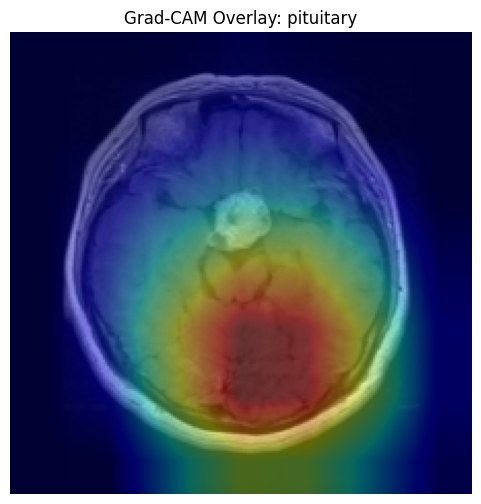

In [27]:
import cv2
import matplotlib.pyplot as plt

img = second_image.squeeze().permute(1, 2, 0).numpy()

cam_resized = cv2.resize(
    cam,
    (img.shape[1], img.shape[0])
)

plt.figure(figsize=(6, 6))
plt.imshow(img, cmap="gray")
plt.imshow(cam_resized, cmap="jet", alpha=0.4)
plt.title(f"Grad-CAM Overlay: {classes[class_idx]}")
plt.axis("off")
plt.show()

In [28]:
second_index = None
found = 0

for i, (image_path, label_id) in enumerate(test_loader.dataset.samples):
    actual_class = classes[label_id]

    if actual_class == "no_tumor":
        continue

    image, label = test_loader.dataset[i]
    image = image.unsqueeze(0)

    output = model(image)
    prediction = output.argmax(dim=1)

    if prediction.item() == label_id:
        found += 1

        if found == 2:
            second_index = i
            second_image = image
            second_label = torch.tensor([label_id])
            second_prediction = prediction
            second_image_path = image_path
            break

print("Actual:", classes[second_label.item()])
print("Predicted:", classes[second_prediction.item()])
print("Image path:", second_image_path)

Actual: glioma
Predicted: glioma
Image path: ../brain_tumor/brisc2025/classification_task/test\glioma\brisc2025_test_00002_gl_ax_t1.jpg


In [29]:
image_name = os.path.basename(second_image_path)
mask_name = image_name.replace(".jpg", ".png")
mask_path = os.path.join(mask_dir, mask_name)

mask = np.array(Image.open(mask_path))

In [30]:
image_name = os.path.basename(second_image_path)
mask_name = image_name.replace(".jpg", ".png")
mask_path = os.path.join(mask_dir, mask_name)

mask = np.array(Image.open(mask_path))

mask_resized = cv2.resize(
    mask,
    (cam_resized.shape[1], cam_resized.shape[0]),
    interpolation=cv2.INTER_NEAREST
)

cam_binary = cam_resized > 0.6
mask_binary = mask_resized > 0

print("Second Image Grad-CAM Dice:", dice_score(cam_binary, mask_binary))
print("Second Image Grad-CAM IoU:", iou_score(cam_binary, mask_binary))

Second Image Grad-CAM Dice: 0.0037735849056603774
Second Image Grad-CAM IoU: 0.001890359168241966


In [31]:
results = []

for i in range(10):

    image_path, label_id = test_loader.dataset.samples[i]

    actual_class = classes[label_id]

    if actual_class == "no_tumor":
        continue

    image, label = test_loader.dataset[i]
    image = image.unsqueeze(0)

    output = model(image)
    prediction = output.argmax(dim=1)

    if prediction.item() != label_id:
        continue

    # Generate Grad-CAM
    model.zero_grad()

    output = model(image)

    class_idx = prediction.item()
    score = output[:, class_idx]

    score.backward()

    weights = gradients.mean(dim=(2, 3), keepdim=True)

    cam = (weights * activations).sum(dim=1).squeeze()

    cam = torch.relu(cam)
    cam = cam - cam.min()
    cam = cam / cam.max()

    cam = cam.detach().numpy()

    # Resize heatmap
    cam_resized = cv2.resize(cam, (224, 224))

    # Load matching mask
    image_name = os.path.basename(image_path)
    mask_name = image_name.replace(".jpg", ".png")

    mask_path = os.path.join(mask_dir, mask_name)

    mask = np.array(Image.open(mask_path))

    mask_resized = cv2.resize(
        mask,
        (224, 224),
        interpolation=cv2.INTER_NEAREST
    )

    # Dice / IoU
    cam_binary = cam_resized > 0.6
    mask_binary = mask_resized > 0

    dice = dice_score(cam_binary, mask_binary)
    iou = iou_score(cam_binary, mask_binary)

    results.append([dice, iou])

    print(
        f"{image_name}: Dice={dice:.3f}, IoU={iou:.3f}"
    )

brisc2025_test_00001_gl_ax_t1.jpg: Dice=0.031, IoU=0.016
brisc2025_test_00002_gl_ax_t1.jpg: Dice=0.005, IoU=0.003
brisc2025_test_00003_gl_ax_t1.jpg: Dice=0.062, IoU=0.032
brisc2025_test_00006_gl_ax_t1.jpg: Dice=0.002, IoU=0.001
brisc2025_test_00007_gl_ax_t1.jpg: Dice=0.037, IoU=0.019
brisc2025_test_00008_gl_ax_t1.jpg: Dice=0.107, IoU=0.056
brisc2025_test_00009_gl_ax_t1.jpg: Dice=0.120, IoU=0.064
brisc2025_test_00010_gl_ax_t1.jpg: Dice=0.047, IoU=0.024


In [32]:
import numpy as np

results = np.array(results)

print("Average Dice:", results[:,0].mean())
print("Average IoU:", results[:,1].mean())

Average Dice: 0.05132800889777543
Average IoU: 0.026785727745689866


In [34]:
from pytorch_grad_cam import ScoreCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

In [35]:
target_layers = [model.layer4[-1]]

scorecam = ScoreCAM(
    model=model,
    target_layers=target_layers
)

input_tensor = correct_image
target_class = correct_prediction.item()

targets = [ClassifierOutputTarget(target_class)]

grayscale_cam = scorecam(
    input_tensor=input_tensor,
    targets=targets
)

score_cam = grayscale_cam[0]

100%|██████████| 32/32 [00:11<00:00,  2.79it/s]


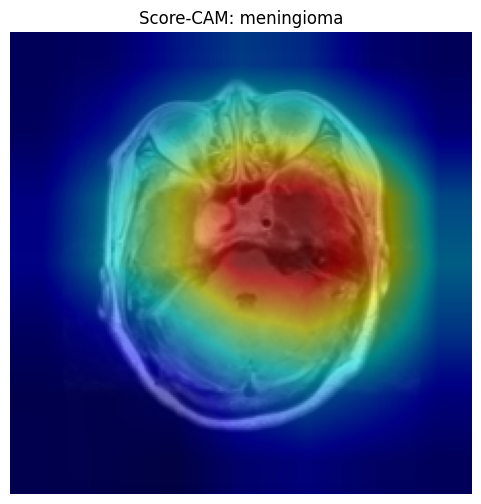

In [36]:
img = correct_image.squeeze().permute(1, 2, 0).detach().cpu().numpy()

visualization = show_cam_on_image(
    img,
    score_cam,
    use_rgb=True
)

plt.figure(figsize=(6, 6))
plt.imshow(visualization)
plt.title(f"Score-CAM: {classes[target_class]}")
plt.axis("off")
plt.show()

In [38]:
scorecam_results = []

threshold = 0.6
num_examples = 10

count = 0

for i, (image_path, label_id) in enumerate(test_loader.dataset.samples):
    actual_class = classes[label_id]

    if actual_class == "no_tumor":
        continue

    image, label = test_loader.dataset[i]
    image = image.unsqueeze(0)

    output = model(image)
    prediction = output.argmax(dim=1)

    if prediction.item() != label_id:
        continue

    target_class = prediction.item()
    targets = [ClassifierOutputTarget(target_class)]

    grayscale_cam = scorecam(
        input_tensor=image,
        targets=targets
    )

    score_cam = grayscale_cam[0]

    image_name = os.path.basename(image_path)
    mask_name = image_name.replace(".jpg", ".png")
    mask_path = os.path.join(mask_dir, mask_name)

    mask = np.array(Image.open(mask_path))

    mask_resized = cv2.resize(
        mask,
        (score_cam.shape[1], score_cam.shape[0]),
        interpolation=cv2.INTER_NEAREST
    )

    score_cam_binary = score_cam > threshold
    mask_binary = mask_resized > 0

    dice = dice_score(score_cam_binary, mask_binary)
    iou = iou_score(score_cam_binary, mask_binary)

    scorecam_results.append([dice, iou])

    print(f"{image_name}: Dice={dice:.3f}, IoU={iou:.3f}")

    count += 1

    if count >= num_examples:
        break

100%|██████████| 32/32 [00:06<00:00,  4.89it/s]


brisc2025_test_00001_gl_ax_t1.jpg: Dice=0.000, IoU=0.000


100%|██████████| 32/32 [00:05<00:00,  5.36it/s]


brisc2025_test_00002_gl_ax_t1.jpg: Dice=0.000, IoU=0.000


100%|██████████| 32/32 [00:10<00:00,  3.11it/s]


...

brisc2025_test_00010_gl_ax_t1.jpg: Dice=0.000, IoU=0.000


100%|██████████| 32/32 [00:19<00:00,  1.62it/s]


brisc2025_test_00011_gl_ax_t1.jpg: Dice=0.000, IoU=0.000


100%|██████████| 32/32 [00:15<00:00,  2.03it/s]

brisc2025_test_00012_gl_ax_t1.jpg: Dice=0.029, IoU=0.015


In [37]:
score_cam_binary = score_cam > 0.6
mask_binary = mask_resized > 0

print("Score-CAM Dice:", dice_score(score_cam_binary, mask_binary))
print("Score-CAM IoU:", iou_score(score_cam_binary, mask_binary))

Score-CAM Dice: 0.003656307129798903
Score-CAM IoU: 0.0018315018315018315


In [40]:
scorecam_results = np.array(scorecam_results)

print("Average Score-CAM Dice:", scorecam_results[:, 0].mean())
print("Average Score-CAM IoU:", scorecam_results[:, 1].mean())

Average Score-CAM Dice: 0.026945794557782836
Average Score-CAM IoU: 0.014112009233628885
